# 3.2.1 状态输入与观测映射

## 学习目标与先修知识

能写出线性状态空间（state space）的动态与观测（observation）方程，核对矩阵（matrix）维数和单位，解释不变的观测为何可能掩盖内部变化。

先修：两室交换、矩阵乘法（matrix multiplication）、平衡（equilibrium）方程；第 1 篇的状态（state）与观测区别。 [复习上一节](../01-从多个室进入线性代数/03-平衡方程秩与唯一性.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

测量仪只记录两室总量，读数始终为 6 U。这能否说明室内已经停止交换？如果改为只测室 1，读者会看见什么？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
states=np.array([[6,0],[4,2],[2,4]])
display(Markdown(show_table(['A1 / U','A2 / U','总量观测 / U','第一室观测 / U'],[(x,y,x+y,x) for x,y in states])))

| A1 / U | A2 / U | 总量观测 / U | 第一室观测 / U |
| --- | --- | --- | --- |
| 6 | 0 | 6 | 6 |
| 4 | 2 | 6 | 4 |
| 2 | 4 | 6 | 2 |

## 模型假设

理想测量无噪声，不研究从读数恢复隐藏状态。两室所追踪物质总量（tracked amount）构成状态；输入（input） u 仅进入室 1。观测可以是第一室量、两室总量或除以固定容积后的浓度（concentration）。用于轨迹（trajectory）的封闭例取 a=.2/T、b=.1/T、u=0、x0=[6,0] U。

## 数学解释与推导

状态空间将系统写成状态、输入与输出（output）之间的关系：
$$\dot x=Mx+Bu,\qquad y=Cx+Du.$$
本例 x 有两个分量，u 与 y 各一个。M 为 2×2，B 为 2×1，C 为 1×2，D 为 1×1；每个乘积必须与左端形状相符。状态记录内部演化所需的量，输出记录实际选择观察的量；改变 C 不改变 M。

B=[1,0] 的含义是外部物质只送入第一室。第一室量用 C=[1,0]，总量用 C=[1,1]；浓度用 C=[1/V1,0]。如果 y 的单位是 U，B 无量纲（dimensionless）、C 无量纲、M 为 1/T，而直接传递系数 D 的单位应为 T。本案例的总量观测均取 D=0；一般输入输出模型（model）可能有非零 D。

为得到无需数值步进的独立轨迹，用封闭总量 S 把第二室替换为 S−A1：
$$\dot A_1=bS-(a+b)A_1.$$
这是已学过的一阶模型。a+b>0 时，
$$A_1(t)=\frac{bS}{a+b}+\left(A_1(0)-\frac{bS}{a+b}\right)e^{-(a+b)t},\quad A_2(t)=S-A_1(t).$$
总量输出恒定，但第一室曲线仍在变化。状态不是仪器屏幕上的那一个数。相同输出可以来自不同内部状态；目前只比较可见信息，后续学习能观性时再研究能否利用一段完整时间记录恢复状态。

输入进入哪里、测量看哪里是独立的选择。不能用输出代替状态直接更新，除非已经证明新的变量能完整描述所需演化。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def state_output(matrix, input_vector, output_vector, direct, state, inflow):
    rates = [sum(row[j]*state[j] for j in range(2))+input_vector[i]*inflow
             for i, row in enumerate(matrix)]
    observed = sum(output_vector[j]*state[j] for j in range(2))+direct*inflow
    return rates, observed
def closed_state(a, b, initial, times):
    import math
    total = sum(initial)
    if a+b == 0:
        return [list(initial) for _ in times]
    states = []
    for t in times:
        remaining = math.exp(-(a+b)*t)
        transferred = -math.expm1(-(a+b)*t)
        states.append([initial[0]*remaining+total*(b/(a+b))*transferred,
                       initial[1]*remaining+total*(a/(a+b))*transferred])
    return states

## 对照实验

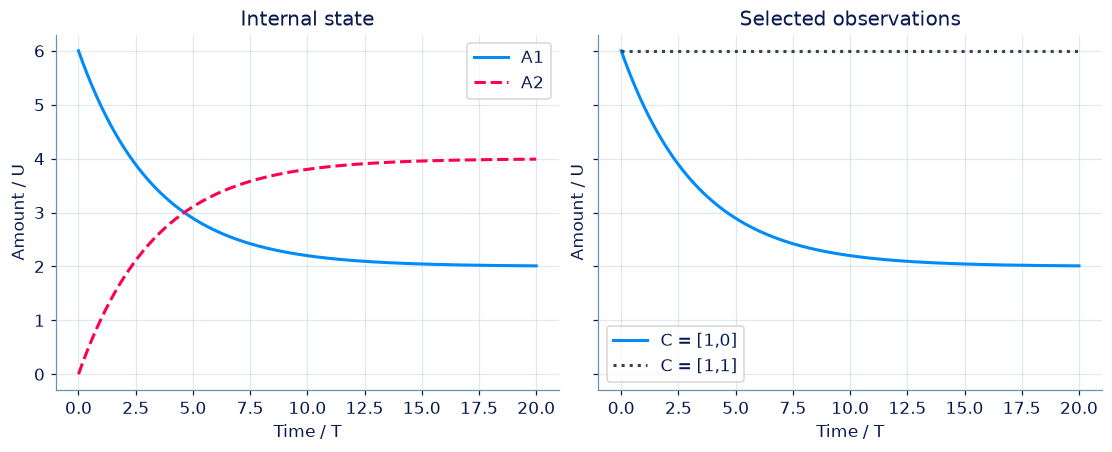

In [4]:
times=np.linspace(0,20,201)
states=np.array(closed_state(.2,.1,[6,0],times))
fig,axes=plt.subplots(1,2,figsize=(10,4),sharey=True)
axes[0].plot(times,states[:,0],color=BLUE,label='A1');axes[0].plot(times,states[:,1],'--',color=PINK,label='A2')
axes[1].plot(times,states@np.array([1,0]),color=BLUE,label='C = [1,0]')
axes[1].plot(times,states@np.array([1,1]),':',color='#384251',label='C = [1,1]')
for ax,title in zip(axes,['Internal state','Selected observations']):
    ax.set(xlabel='Time / T',ylabel='Amount / U',title=title);ax.legend()
plt.show()

## 结果解释

左图两个室改变分配，右图总量读数保持平直。第一室的蓝线在两图相同，这提醒我们观测是从状态计算出的量，而不是另一套动态。

### 独立核对

总收支（mass balance）与解析轨迹提供独立参照；一种输出平直不能证明每个状态都不变。

In [5]:
np.testing.assert_allclose(states.sum(axis=1),6)
np.testing.assert_allclose(states[0],[6,0])
M=[[-.2,.1],[.2,-.1]]
for x in [[6,0],[2,4]]:
    r,total=state_output(M,[1,0],[1,1],0,x,1)
    assert math.isclose(sum(r),1)
    assert total==sum(x)
assert state_output(M,[1,0],[.5,0],0,[2,4],0)[1]==1
print('初值、守恒、输入分配和浓度观测单位换算通过。')

初值、守恒、输入分配和浓度观测单位换算通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-02-线性状态空间与动态模态/explore/)：改变一个条件，观察时间曲线与状态空间中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：同一状态，不同测量

二维线性状态空间（state space）模型（model）为 x′=Mx+Bu、y=Cx+Du。状态（state）分量均为所追踪物质总量（tracked amount） U，u 为流入速率 U/T，y 为总量 U。计算瞬时变化率和标量观测（observation）。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    input_vector: list[float],
    output_vector: list[float],
    direct: float,
    state: list[float],
    inflow: float,
) -> tuple[list[float], float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 2×2 状态矩阵（matrix） M。 | 1/T |
| `input_vector` | `list[float]` | 输入（input）分配 B，长度 2。 | 1 |
| `output_vector` | `list[float]` | 观测加权 C，长度 2。 | 1 |
| `direct` | `float` | 直接输入到观测的系数 D；不参与状态更新。 | T |
| `state` | `list[float]` | 当前二维状态。 | U |
| `inflow` | `float` | 当前输入 u。 | U/T |

**返回值**

按以下顺序返回元组：(rates, observed)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 两个状态的变化率。 | U/T |
| `observed` | `float` | 当前观测 y。 | U |

**计算规则**

rates[i]=sum(matrix[i][j]*state[j] for j in range(2))+input_vector[i]*inflow；observed=sum(output_vector[j]*state[j] for j in range(2))+direct*inflow。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 矩阵和列表形状如说明；每个输入数的绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 2×2 状态矩阵（matrix） M。 | [[-0.2, 0.1], [0.2, -0.1]] | 1/T |
| input_vector | 输入（input）分配 B，长度 2。 | [1, 0] | 1 |
| output_vector | 观测加权 C，长度 2。 | [1, 1] | 1 |
| direct | 直接输入到观测的系数 D；不参与状态更新。 | 0 | T |
| state | 当前二维状态。 | [6, 0] | U |
| inflow | 当前输入 u。 | 1 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[-0.2, 0.1], [0.2, -0.1]]
input_vector = [1, 0]
output_vector = [1, 1]
direct = 0
state = [6, 0]
inflow = 1

result = solve(matrix, input_vector, output_vector, direct, state, inflow)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 两个状态的变化率。 | [-0.20000000000000018, 1.2000000000000002] | U/T |
| observed | 当前观测 y。 | 6 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-0.20000000000000018,
                    1.2000000000000002],
                   6)
```

**样例解释**

交换给出 [−1.2,1.2] U/T，输入使第一分量变为 −0.2；总量观测为 6 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同一状态，不同测量](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-state-output)

### 第 2 题 · 多项选择题：一条测量能代表全部状态吗

测得封闭两室的 y=A1+A2，曲线恒为 6 U。哪些推论成立？

- **A.** 总量观测（observation）可以不变，但两室仍在交换。
- **B.** 内部每个状态（state）必定不变。
- **C.** 测量只给出两分量之和，不能直接读出各室所追踪物质总量（tracked amount）。
- **D.** 若观察 A1，可能看见交换过程。

[作答：一条测量能代表全部状态吗](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-observation-not-state)

### 第 3 题 · 单项选择题：状态空间中的维数

两个状态（state）、一个输入（input）、一个输出（output）的 x′=Mx+Bu，y=Cx+Du 中，哪组维数正确？

- **A.** M:2×2，B:2×1，C:1×2，D:1×1。
- **B.** M:1×2，B:2×2，C:2×1，D:2×2。
- **C.** 所有矩阵（matrix）都必须 2×2。
- **D.** C 的行数必须等于状态数。

[作答：状态空间中的维数](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-dimensions)

### 第 4 题 · 单项选择题：测量浓度如何写输出

x=[A1,A2]，V1=2 L。测量室 1 的浓度（concentration），不含直接输入（input）项。正确输出（output）关系是？

- **A.** y=[1,0]x，单位 U/L。
- **B.** y=[1/2,0]x，C 的单位为 1/L。
- **C.** y=[2,0]x，单位 L。
- **D.** y=A1+A2，始终等于室 1 浓度。

[作答：测量浓度如何写输出](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-output-units)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。